# Stage 1: Baseline Models

## Purpose

Stage 1 establishes the global baseline layer of the thesis pipeline. Its role is to learn contract-level structure from the weakly supervised contract universe, quantify how far weak supervision alone can go, and create a pretrained MLP backbone that Stage 2 meta-learning can adapt to individual departments.

## Stage 1 condition overview

The table below summarises the four experimental conditions. Each condition trains the same model family (Mean Predictor, Elastic Net, XGBoost, MLP) under a different supervision regime, allowing controlled ablation of weak vs. gold label value.

| Condition | Rows used | Target | Weighting | Scope | Target-dept gold excluded |
|-----------|-----------|--------|-----------|-------|---------------------------|
| **A** Weak-only | All contracts | `renegotiation_prob` (soft 0-1) | None (uniform) | Global | N/A (no gold used) |
| **B** Gold-only | Non-target-dept gold rows | `gold_y` (binary 0/1) | None (uniform) | Target-specific | Yes |
| **C** Hybrid (weighted) | All weak + non-target-dept gold | Mixed weak + gold | `w_gold` > `w_weak` via sampler | Target-specific | Yes |
| **D** Hybrid (unweighted) | All weak + non-target-dept gold | Mixed weak + gold | None (uniform) | Target-specific | Yes |

Key design points:

- **Condition A is global.** It uses all contracts and is reusable across target departments. Its artifacts are stored under `models/stage_1/global/A_weak_only/`.
- **Conditions B, C, D are target-aware.** They exclude the current target department's gold labels from training, reserving them for Stage 2. Their artifacts are stored under `models/stage_1/{target_department}/{condition}/`.
- **C and D share identical training data.** The only difference is whether `WeightedRandomSampler` upweights gold rows. Any performance gap isolates the effect of the weighting scheme alone.

<!--
FUTURE: synthetic-support planning table
When SMOTENC augmentation is implemented, a second summary table will connect
target department, real gold support size, synthetic proportion, and effective
support size for each department-as-target experiment.
-->

## Design principle

The Stage 1 design distinguishes between weak supervision and target-department gold supervision:

- All contracts (including the target department) remain in the Stage 1 weak-label universe.
- Weak labels generated by Snorkel remain part of Stage 1 weak training for all departments.
- The target department's gold labels are excluded from Stage 1 supervised gold training.
- The target department's gold labels are reserved for Stage 2 adaptation and evaluation.

This distinction is central to the thesis argument. Stage 1 should learn a global renegotiation representation, while Stage 2 should be the first point at which the model receives target-department gold signal.

---
**Restart-and-Run-All Safety**  
This notebook must execute cleanly from a fresh kernel (Kernel → Restart & Run All). All constants are derived from `experiments/stage1_config.yaml`. To change the target department or any hyperparameter, edit `stage1_config.yaml` — do not hardcode values in notebook cells.  
Imports are centralised in cells 2–4. Mid-notebook imports indicate a structural issue and should be reported.


## 1. Imports and project setup

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"   # ← tells OpenMP to allow duplicates


In [2]:
import yaml
from sklearn.model_selection import GroupShuffleSplit as _GSS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
torch.set_num_threads(4)

from master_thesis.config import FIGURES, MODELS_STAGE1, SEED
from master_thesis.data_utils import (
    load_processed,
    require_columns,
    make_gold_contract_split,
    save_table_versioned,
    save_json_versioned,
)
from master_thesis.baselines import (
    ElasticNetConfig,
    XGBoostConfig,
    BaselineTrainingConfig,
)
from master_thesis.mlp import (
    MLPTrainingConfig,
    set_seed,
)
from master_thesis.stage1 import (
    GLOBAL_CONDITIONS,
    Stage1ModelConfig,
    fit_stage1_conditions,
    evaluate_stage1_conditions,
    get_stage1_condition_dir,
    make_stage1_predictions_df,
    save_stage1_condition_artifacts,
    save_stage1_condition_summary,
    save_stage1_metadata,
)


## 2. Notebook Helpers

The helper functions below are kept in the notebook because they are specific to the Stage 1 experimental workflow. They handle feature availability flags, Stage 1 feature selection, and versioned figure export. Keeping them local makes the experimental setup easier to inspect and reproduce.


In [4]:
def get_stage1_feature_columns(
    df_input: pd.DataFrame,
    group_col: str,
    weak_target_col: str,
    gold_col: str,
) -> list[str]:
    """Return the list of Stage 1 feature columns for df_input.

    LEAKAGE GUARD
    -------------
    ``label_source``, ``label_note``, and ``label_date`` are gold-label
    metadata columns written during NB15.1 manual annotation.  They are
    non-null only for the ~99 manually labelled rows and NaN everywhere
    else.  Including them would give any classifier a near-perfect binary
    separator between labelled and unlabelled contracts — pure data
    leakage.  They are unconditionally excluded here and in the
    corresponding CLI path (experiments/run_stage1.py :: load_and_split).

    If the dataset ever gains new gold-label metadata columns, add them to
    ``_LEAKAGE_METADATA_COLS`` below.
    """
    _LEAKAGE_METADATA_COLS = {"label_source", "label_note", "label_date"}

    leakage_cols = [
        "Unnamed: 0",
        group_col,
        "contract_number",
        "contract_name",
        "supplier_id",
        "supplier_number",
        "supplier_display_name",
        "moodys_bvd_id",
        "Company name Latin alphabet",
        "company_name",
        "gold_department",
        "target_renegotiate",
        weak_target_col,
        gold_col,
        "start_date",
        "expiration_date",
        "execution_at",
        "published_at",
        "contract_name_lower",
        "lf_yes_votes",
        "lf_no_votes",
        "lf_abstain_votes",
        "global_lifecycle_yes_votes",
        "global_lifecycle_no_votes",
        "global_financial_yes_votes",
        "global_financial_no_votes",
        "global_esg_yes_votes",
        "global_esg_no_votes",
        "global_news_yes_votes",
        "global_news_no_votes",
        "global_market_yes_votes",
        "global_market_no_votes",
        "global_supplier_macro_yes_votes",
        "global_supplier_macro_no_votes",
        "logistics_specific_yes_votes",
        "logistics_specific_no_votes",
        # Gold-label metadata — LEAKAGE GUARD (do NOT remove)
        *_LEAKAGE_METADATA_COLS,
    ]
    leakage_set = set(leakage_cols)
    selected = [c for c in df_input.columns if c not in leakage_set]

    # Post-selection assertion: guard against future accidental re-inclusion.
    _leaked = [c for c in _LEAKAGE_METADATA_COLS if c in selected]
    assert not _leaked, (
        f"[LEAKAGE GUARD] Gold-label metadata column(s) {_leaked} slipped into "
        f"the Stage 1 feature set.  Add them to leakage_cols in "
        f"get_stage1_feature_columns() and in run_stage1.py :: load_and_split()."
    )

    return selected


def save_figure_versioned(fig, stem: str, output_dir: Path | None = None, dpi: int = 300) -> Path:
    if output_dir is None:
        output_dir = FIGURES

    output_dir.mkdir(parents=True, exist_ok=True)
    pattern = re.compile(rf"^{re.escape(stem)}_v(\d{{3}})\.png$")
    versions = []

    for path in output_dir.glob(f"{stem}_v*.png"):
        match = pattern.match(path.name)
        if match:
            versions.append(int(match.group(1)))

    next_version = max(versions, default=0) + 1
    output_path = output_dir / f"{stem}_v{next_version:03d}.png"
    fig.savefig(output_path, bbox_inches="tight", dpi=dpi)
    return output_path


## 3. Data loading and Stage 1 setup

This section loads the weak-labeled dataset used by the Stage 1 baselines. The dataset contains the full contract universe with Snorkel probabilities and any available gold labels. The `TARGET_DEPARTMENT` variable below controls which department's gold labels are excluded from the supervised Stage 1 conditions (B, C, D) and reserved for Stage 2 adaptation.

In [5]:
set_seed(SEED)
np.random.seed(SEED)

# ---------------------------------------------------------------------------
# Load stage1_config.yaml — single source of truth for experiment settings.
# Constants below are derived from YAML. Do not hardcode values elsewhere.
# ---------------------------------------------------------------------------
_s1_cfg_path = project_root / 'experiments' / 'stage1_config.yaml'
with open(_s1_cfg_path) as _f:
    _stage1_yaml = yaml.safe_load(_f)

# Column / filename constants — read from YAML
DATA_FILENAME   = _stage1_yaml.get('data_filename',   'contract_with_features_labeled_with_gold.csv')
WEAK_TARGET_COL = _stage1_yaml.get('weak_target_col', 'renegotiation_prob')
GOLD_COL        = _stage1_yaml.get('gold_col',        'gold_y')
GROUP_COL       = _stage1_yaml.get('group_col',       'contract_id')
DEPARTMENT_COL  = _stage1_yaml.get('department_col',  'department')

print("=" * 60)
print("Stage 1 Effective Configuration")
print("=" * 60)
print(f"  Config file   : {_s1_cfg_path}")
print(f"  Data file     : {DATA_FILENAME}")
print(f"  Weak target   : {WEAK_TARGET_COL}")
print(f"  Gold target   : {GOLD_COL}")
print(f"  Group col     : {GROUP_COL}")
print(f"  Dept col      : {DEPARTMENT_COL}")
print(f"  Seed          : {SEED}")
print()

df_stage1 = load_processed(DATA_FILENAME, low_memory=False)


In [6]:
# Stage 1 dataset diagnostics
print("Stage 1 dataset overview")
print(f"Total rows: {len(df_stage1)}")
print(f"Unique contracts: {df_stage1[GROUP_COL].nunique()}")

if DEPARTMENT_COL in df_stage1.columns:
    print("\nDepartment distribution (top 10)")
    print(df_stage1[DEPARTMENT_COL].value_counts().head(10))

print(f"\nWeak label column present ('{WEAK_TARGET_COL}'): {WEAK_TARGET_COL in df_stage1.columns}")
print(f"Gold label column present ('{GOLD_COL}'): {GOLD_COL in df_stage1.columns}")

Stage 1 dataset overview
Total rows: 9201
Unique contracts: 2209

Department distribution (top 10)
department
Devices & Needles                          2197
Raw Materials & Energy                     1555
Packaging Material                         1272
Quality, Production Services & Supplies    1044
Drug Substance Outsourcing                  943
Bioprocessing & Raw Materials               679
Drug Product Outsourcing                    589
Logistics                                   282
Alliance, Acquisitions & PPM CoE            270
Bioprocessing and Excipients                218
Name: count, dtype: int64

Weak label column present ('renegotiation_prob'): True
Gold label column present ('gold_y'): True


In [7]:
df_stage1.head()

,contract_id,contract_name,contract_status,contract_owner_cost_centre,terminated,term_type,start_date,expiration_date,supplier_id,supplier_number,...,esg_data_available,news_data_available,market_data_available,has_environmental_appendix,contract_name_lower,renegotiation_prob,target_renegotiate,gold_y,label_source,label_note
0,9675,Bioreliance_Master_2018_MSA,published,7756.0,0,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,11544,38367,...,1,1,0,0,bioreliance_master_2018_msa,0.621413,1,NaN,NaN,NaN
1,9675,Bioreliance_Master_2018_MSA,published,7756.0,0,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,11544,38367,...,1,1,0,0,bioreliance_master_2018_msa,0.621413,1,NaN,NaN,NaN
2,9675,Bioreliance_Master_2018_MSA,published,7756.0,0,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,11544,38367,...,1,1,0,0,bioreliance_master_2018_msa,0.621413,1,NaN,NaN,NaN
3,9675,Bioreliance_Master_2018_MSA,published,7756.0,0,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,11544,38367,...,1,1,0,0,bioreliance_master_2018_msa,0.621413,1,NaN,NaN,NaN
4,9675,Bioreliance_Master_2018_MSA,published,7756.0,0,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,11544,38367,...,1,1,0,0,bioreliance_master_2018_msa,0.565277,1,NaN,NaN,NaN


In [8]:
require_columns(
    df_stage1,
    [WEAK_TARGET_COL, GOLD_COL, GROUP_COL, DEPARTMENT_COL],
    df_name="df_stage1",
)

print("Shape:", df_stage1.shape)
print("Unique contracts:", df_stage1[GROUP_COL].nunique())
print("Gold-labeled rows:", int(df_stage1[GOLD_COL].notna().sum()))
display(df_stage1.head(3))

Shape: (9201, 166)
Unique contracts: 2209
Gold-labeled rows: 99


,contract_id,contract_name,contract_status,contract_owner_cost_centre,terminated,term_type,start_date,expiration_date,supplier_id,supplier_number,...,esg_data_available,news_data_available,market_data_available,has_environmental_appendix,contract_name_lower,renegotiation_prob,target_renegotiate,gold_y,label_source,label_note
0,9675,Bioreliance_Master_2018_MSA,published,7756.0,0,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,11544,38367,...,1,1,0,0,bioreliance_master_2018_msa,0.621413,1,NaN,NaN,NaN
1,9675,Bioreliance_Master_2018_MSA,published,7756.0,0,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,11544,38367,...,1,1,0,0,bioreliance_master_2018_msa,0.621413,1,NaN,NaN,NaN
2,9675,Bioreliance_Master_2018_MSA,published,7756.0,0,fixed,2018-05-21 00:00:00+00:00,2027-07-30 00:00:00+00:00,11544,38367,...,1,1,0,0,bioreliance_master_2018_msa,0.621413,1,NaN,NaN,NaN


## 3A. Gold split design and target-department handling

The split logic below implements the thesis data-separation rule for the current `TARGET_DEPARTMENT`.

The weak-label universe remains global, including the target department. This allows weak-only models to learn from the full contract portfolio and from the Snorkel probabilities assigned to all rows.

The supervised Stage 1 gold training sets exclude the target department. This prevents target-department gold leakage into Stage 1 while still allowing Stage 1 to serve as the global pretraining layer for Stage 2.

As a result:

- **Condition A** uses weak labels from all departments, including the target department.
- **Conditions B, C, D** use gold training labels only from non-target departments.
- Target-department gold labels are reserved for Stage 2.

This design generalises to any department-as-target experiment. To run Stage 1 for a different target department, change `TARGET_DEPARTMENT` and re-run the notebook.

In [9]:
# TARGET_DEPARTMENT — loaded from experiments/stage1_config.yaml.
# To change the target department, edit stage1_config.yaml: target_department.
TARGET_DEPARTMENT = _stage1_yaml.get("target_department", "Logistics")
print(f"[NB16] Target department : {TARGET_DEPARTMENT!r}")
print(f"[NB16] MLP config        : {_stage1_yaml.get('mlp_config', {})}")
assert TARGET_DEPARTMENT in [
    "Logistics", "Packaging Material",
    "Devices & Needles", "Bioprocessing & Raw Materials",
], f"Unexpected TARGET_DEPARTMENT {TARGET_DEPARTMENT!r} — verify spelling matches dataset."

gold_train_contract_ids, gold_test_contract_ids = make_gold_contract_split(
    df_stage1=df_stage1,
    seed=SEED,
    test_size=0.30,
)

df_gold = df_stage1[df_stage1[GOLD_COL].notna()].copy()

# Reserve target-department gold labels for Stage 2 only.
df_gold_target = df_gold[df_gold[DEPARTMENT_COL] == TARGET_DEPARTMENT].copy()
df_gold_non_target = df_gold[df_gold[DEPARTMENT_COL] != TARGET_DEPARTMENT].copy()

df_gold_train = df_gold_non_target[df_gold_non_target[GROUP_COL].isin(gold_train_contract_ids)].copy()
df_gold_test = df_gold_non_target[df_gold_non_target[GROUP_COL].isin(gold_test_contract_ids)].copy()

# Weak training remains global and may include target-department weak labels.
# Only the held-out Stage 1 gold test contracts are removed from weak training.
df_weak_all = df_stage1.copy()
df_weak_train = df_weak_all[~df_weak_all[GROUP_COL].isin(gold_test_contract_ids)].copy()

print(f"Target department: {TARGET_DEPARTMENT}")
print(f"Gold train contracts before target exclusion: {len(gold_train_contract_ids)}")
print(f"Gold test contracts before target exclusion: {len(gold_test_contract_ids)}")
print(f"Non-target gold train rows: {len(df_gold_train)}")
print(f"Non-target gold test rows: {len(df_gold_test)}")
print(f"Target-department gold rows reserved for Stage 2: {len(df_gold_target)}")
print(f"Weak train rows: {len(df_weak_train)}")
print()

print("Non-target gold train label counts")
print(df_gold_train[GOLD_COL].value_counts(dropna=False))
print("\nNon-target gold test label counts")
print(df_gold_test[GOLD_COL].value_counts(dropna=False))

# Verify target-department exclusion from supervised splits.
if DEPARTMENT_COL in df_gold_train.columns:
    target_gold_train = int((df_gold_train[DEPARTMENT_COL] == TARGET_DEPARTMENT).sum())
    target_gold_test = int((df_gold_test[DEPARTMENT_COL] == TARGET_DEPARTMENT).sum())
    target_weak_train = int((df_weak_train[DEPARTMENT_COL] == TARGET_DEPARTMENT).sum())

    print(f"\nTarget-department separation diagnostics")
    print(f"  {TARGET_DEPARTMENT} rows in gold train: {target_gold_train}")
    print(f"  {TARGET_DEPARTMENT} rows in gold test:  {target_gold_test}")
    print(f"  {TARGET_DEPARTMENT} rows in weak train: {target_weak_train}")

    if target_gold_train > 0 or target_gold_test > 0:
        raise ValueError(
            f"{TARGET_DEPARTMENT} gold labels were found in Stage 1 supervised splits. "
            "These labels must be reserved for Stage 2."
        )

Target department: Packaging Materials
Gold train contracts before target exclusion: 11
Gold test contracts before target exclusion: 6
Non-target gold train rows: 83
Non-target gold test rows: 16
Target-department gold rows reserved for Stage 2: 0
Weak train rows: 9185

Non-target gold train label counts
gold_y
1.0    61
0.0    22
Name: count, dtype: int64

Non-target gold test label counts
gold_y
0.0    9
1.0    7
Name: count, dtype: int64

Target-department separation diagnostics
  Packaging Materials rows in gold train: 0
  Packaging Materials rows in gold test:  0
  Packaging Materials rows in weak train: 0


## 4. Feature matrix setup

After the split has enforced the target-department exclusion rule, this section constructs the Stage 1 feature matrices. The weak matrices remain global, whereas the supervised gold matrices are restricted to non-target-department gold rows. All downstream training conditions share the same preprocessing logic while respecting the thesis data-separation principle.

In [11]:
feature_cols = get_stage1_feature_columns(
    df_input=df_stage1,
    group_col=GROUP_COL,
    weak_target_col=WEAK_TARGET_COL,
    gold_col=GOLD_COL,
)

X_weak_train_df = df_weak_train[feature_cols].copy()
y_weak_train = df_weak_train[WEAK_TARGET_COL].astype(float).values

X_weak_all_df = df_weak_all[feature_cols].copy()
y_weak_all = df_weak_all[WEAK_TARGET_COL].astype(float).values

X_gold_train_df = df_gold_train[feature_cols].copy()
y_gold_train = df_gold_train[GOLD_COL].astype(int).values

X_gold_test_df = df_gold_test[feature_cols].copy()
y_gold_test = df_gold_test[GOLD_COL].astype(int).values

print("Number of Stage 1 features:", len(feature_cols))
print("Weak train shape:", X_weak_train_df.shape)
print("Gold train shape:", X_gold_train_df.shape)
print("Gold test shape :", X_gold_test_df.shape)

Number of Stage 1 features: 151
Weak train shape: (9185, 151)
Gold train shape: (83, 151)
Gold test shape : (16, 151)


In [10]:
# ---------------------------------------------------------------------------
# Fix 5: Build an internal gold validation split for B/C/D early stopping.
#
# The global gold split (make_gold_contract_split) gave us:
#   - gold_train_contract_ids  → 11 contracts  (76 rows, 54 pos / 22 neg)
#   - gold_test_contract_ids   → 6 contracts   (1 non-target row = 1 positive)
#
# Passing the 1-row gold test set as the MLP validation set for B/C/D is
# meaningless:
#   • BCEWithLogitsLoss on 1 sample is an unreliable early-stopping signal.
#   • AUROC / all ranking metrics require ≥ 2 samples and ≥ 2 classes.
#
# Instead we carve out a small internal validation split from the 76 gold
# training rows (grouped by contract_id so no contract appears in both splits).
# The 1-row test set is kept strictly as a held-out diagnostic subset and is
# NOT used for early stopping.
#
# Fallback: if the gold training data is too small to support a grouped split
# with both classes in the val fold, we log a warning and fall back to using
# the training loss as the early-stopping signal (no external validation set).
# ---------------------------------------------------------------------------
# Only attempt the internal split when we have enough gold train data.
_MIN_GOLD_CONTRACTS_FOR_INTERNAL_VAL = 4   # need at least a few in each fold

_gold_train_contracts = df_gold_train[GROUP_COL].unique()
_gold_train_labels_by_contract = (
    df_gold_train.groupby(GROUP_COL)[GOLD_COL].first().reindex(_gold_train_contracts)
)

_gold_internal_val_ok = False
X_gold_internal_val_df = None
y_gold_internal_val    = None

if len(_gold_train_contracts) >= _MIN_GOLD_CONTRACTS_FOR_INTERNAL_VAL:
    _gss = _GSS(n_splits=5, test_size=0.25, random_state=SEED)
    for _attempt, (_tr_idx, _va_idx) in enumerate(
        _gss.split(
            df_gold_train[[GROUP_COL]],
            df_gold_train[GOLD_COL],
            groups=df_gold_train[GROUP_COL],
        )
    ):
        _y_va = df_gold_train.iloc[_va_idx][GOLD_COL].values
        # Accept only if the val fold contains both classes.
        if len(set(_y_va)) == 2:
            _gold_internal_val_ok = True
            _df_gold_internal_tr  = df_gold_train.iloc[_tr_idx]
            _df_gold_internal_val = df_gold_train.iloc[_va_idx]
            X_gold_internal_val_df = _df_gold_internal_val[feature_cols].copy()
            y_gold_internal_val    = _df_gold_internal_val[GOLD_COL].astype(float).values
            print(
                f"[Internal gold val]  attempt {_attempt+1}: "
                f"{len(_df_gold_internal_val)} rows, "
                f"classes={sorted(set(map(int, _y_va)))}"
            )
            break

if not _gold_internal_val_ok:
    print(
        "[WARNING] Could not build an internal gold validation split with both "
        "classes.  B/C/D early stopping will use training-loss proxy (no external "
        "validation set).  This is a known limitation when gold data is very "
        "sparse; interpret MLP B/C/D results with caution."
    )
    # Fallback: use the weak validation set (suboptimal but avoids crashing).
    # This will be overridden in condition_val_overrides below if needed.

print()
print(f"Internal gold val split: {'OK' if _gold_internal_val_ok else 'FALLBACK (weak val)'}")
print(f"  Gold train rows:    {len(df_gold_train)}")
if X_gold_internal_val_df is not None:
    print(f"  Internal val rows:  {len(X_gold_internal_val_df)}")
print(f"  Held-out test rows: {len(df_gold_test)}  (diagnostic only — NOT used for early stopping)")


Stage 1 features: 151 columns
[Internal gold val]  attempt 4: 33 rows, classes=[0, 1]

Internal gold val split: OK
  Gold train rows:    83
  Internal val rows:  33
  Held-out test rows: 16  (diagnostic only — NOT used for early stopping)


## 5. Hyperparameters

**All hyperparameters are loaded from `experiments/stage1_config.yaml` — the single source of truth.**
Do not hardcode values in this cell; change `stage1_config.yaml` and re-run.

This ensures the CLI runner (`experiments/run_stage1.py`) and this notebook always produce
artifacts with identical configuration, and that `metadata.json` saved alongside each artifact
faithfully reflects the hyperparameters actually used for training.


In [12]:
# ---------------------------------------------------------------------------
# Load Stage 1 hyperparameters from stage1_config.yaml (single source of truth).
# To change any hyperparameter, edit experiments/stage1_config.yaml only.
# ---------------------------------------------------------------------------
# _stage1_yaml loaded in setup cell (044cc23e) from experiments/stage1_config.yaml
_config_path = _s1_cfg_path  # alias for experiment_config below

_bc = _stage1_yaml.get('baseline_config', {})
_en = _bc.get('elastic_net', {})
_xgb = _bc.get('xgboost', {})
_mc = _stage1_yaml.get('mlp_config', {})

baseline_config = BaselineTrainingConfig(
    scale_numeric_for_elastic_net=_bc.get('scale_numeric_for_elastic_net', True),
    scale_numeric_for_xgboost=_bc.get('scale_numeric_for_xgboost', False),
    add_numeric_missing_indicator=_bc.get('add_numeric_missing_indicator', True),
    elastic_net=ElasticNetConfig(
        alpha=_en.get('alpha', 0.005),
        l1_ratio=_en.get('l1_ratio', 0.5),
        max_iter=_en.get('max_iter', 10000),
        random_state=SEED,
    ),
    xgboost=XGBoostConfig(
        n_estimators=_xgb.get('n_estimators', 500),
        learning_rate=_xgb.get('learning_rate', 0.05),
        max_depth=_xgb.get('max_depth', 6),
        min_child_weight=_xgb.get('min_child_weight', 3),
        subsample=_xgb.get('subsample', 0.8),
        colsample_bytree=_xgb.get('colsample_bytree', 0.8),
        reg_alpha=_xgb.get('reg_alpha', 0.0),
        reg_lambda=_xgb.get('reg_lambda', 1.0),
        random_state=SEED,
        n_jobs=_xgb.get('n_jobs', -1),
    ),
)

mlp_config = MLPTrainingConfig(
    n_epochs=_mc.get('n_epochs', 200),
    patience=_mc.get('patience', 20),
    lr=float(_mc.get('lr', 3e-4)),
    weight_decay=float(_mc.get('weight_decay', 1e-4)),
    train_batch_size=int(_mc.get('train_batch_size', 256)),
    val_batch_size=int(_mc.get('val_batch_size', 512)),
    hidden_dim_1=int(_mc.get('hidden_dim_1', 256)),
    hidden_dim_2=int(_mc.get('hidden_dim_2', 128)),
    dropout=float(_mc.get('dropout', 0.1)),
)

stage1_config = Stage1ModelConfig(
    baseline_config=baseline_config,
    mlp_config=mlp_config,
)

# Hybrid weights (from YAML).
HYBRID_WEAK_WEIGHT = float(_stage1_yaml.get('hybrid_weak_weight', 1.0))
HYBRID_GOLD_WEIGHT = float(_stage1_yaml.get('hybrid_gold_weight', 5.0))

experiment_config = {
    'seed': SEED,
    'data_filename': DATA_FILENAME,
    'weak_target_col': WEAK_TARGET_COL,
    'gold_col': GOLD_COL,
    'group_col': GROUP_COL,
    'department_col': DEPARTMENT_COL,
    'hybrid_weak_weight': HYBRID_WEAK_WEIGHT,
    'hybrid_gold_weight': HYBRID_GOLD_WEIGHT,
    'mlp_config': dict(_mc),
    'baseline_config': dict(_bc),
    'config_source': str(_config_path),
}

print(f'Loaded config from: {_config_path}')
print(f'MLP architecture  : {mlp_config.hidden_dim_1} → {mlp_config.hidden_dim_2} → 1')
print(f'MLP lr / epochs   : {mlp_config.lr} / {mlp_config.n_epochs} (patience {mlp_config.patience})')
print(f'Hybrid weights    : weak={HYBRID_WEAK_WEIGHT}, gold={HYBRID_GOLD_WEIGHT}')


Loaded config from: /Users/Thomas/Desktop/Master Thesis/experiments/stage1_config.yaml
MLP architecture  : 256 → 128 → 1
MLP lr / epochs   : 0.0003 / 200 (patience 20)
Hybrid weights    : weak=1.0, gold=5.0


## 6. Define Stage 1 conditions

Four training conditions provide controlled experimental baselines. They isolate the contribution of each supervision source and allow direct ablation comparisons. The conditions are summarised in the table at the top of this notebook.

**Condition A -- Weak-only training (global)**
- **Target:** Snorkel probabilistic labels (`renegotiation_prob`, continuous 0-1) for every contract.
- Includes the target department's weak labels.
- Provides the main Stage 1 pretraining path and the principal initialisation candidate for Stage 2.
- Artifacts are stored under `models/stage_1/global/A_weak_only/` and are reusable across target departments.

**Condition B -- Gold-only training (target-aware)**
- **Target:** Binary hard labels (`gold_y`, 0/1) for non-target-department contracts only.
- Excludes target-department contracts entirely (held out for Stage 2 meta-testing).
- Ablation: how far does scarce gold supervision go on its own?

**Condition C -- Hybrid weighted (target-aware)**
- **Target:** Concatenation of weak labels (all rows) + gold labels (non-target-department rows only).
- `sample_weight` assigns `HYBRID_GOLD_WEIGHT` to gold rows and `HYBRID_WEAK_WEIGHT` to weak rows, activating `WeightedRandomSampler`.
- Ablation: does explicit up-weighting of gold labels improve alignment?

**Condition D -- Hybrid unweighted (target-aware)**
- **Target:** Identical concatenation to C -- the same `X_train` and `y_train` arrays.
- `sample_weight=None` -- uniform sampling, no `WeightedRandomSampler`.
- C and D share the same target definition. The difference is the *weighting scheme*, not a different objective. Any performance gap between C and D isolates the effect of the sampler alone.

In [13]:
conditions = {
    "A_weak_only": {
        "X_train_df": X_weak_train_df,
        "y_train": y_weak_train,
        "sample_weight": None,
    },
    "B_gold_only": {
        "X_train_df": X_gold_train_df,
        "y_train": y_gold_train.astype(float),
        "sample_weight": None,
    },
    "C_hybrid": {
        "X_train_df": pd.concat([X_weak_train_df, X_gold_train_df], axis=0).reset_index(drop=True),
        "y_train": np.concatenate([y_weak_train, y_gold_train.astype(float)]),
        "sample_weight": np.concatenate([
            np.full(len(y_weak_train), HYBRID_WEAK_WEIGHT, dtype=float),
            np.full(len(y_gold_train), HYBRID_GOLD_WEIGHT, dtype=float),
        ]),
    },    
    "D_hybrid_unweighted": {
        "X_train_df": pd.concat([X_weak_train_df, X_gold_train_df], axis=0).reset_index(drop=True),
        "y_train": np.concatenate([y_weak_train, y_gold_train.astype(float)]),
        "sample_weight": None, # The unweighted baseline (exactly the same as C, but with no weights!)
    },
}

## 7. Train All Stage 1 Conditions

Each Stage 1 condition trains the same family of models but with a different supervision source.

### Validation target design

The MLP uses BCEWithLogitsLoss + early stopping.  The validation signal must be consistent
with the condition's training objective and must have ≥2 samples and ≥2 classes.

| Condition | Training labels | Validation set | Rationale |
|-----------|----------------|----------------|-----------|
| A_weak_only | `renegotiation_prob` (Snorkel, soft) | Weak val (rows from held-out gold-test contracts) | Weak-label distillation objective; early stopping tracks the same signal it optimises. |
| B_gold_only | `gold_y` (binary) | **Internal gold val** (25% of gold train rows, grouped by contract) | Gold supervision; internal val has ≥2 classes → meaningful early stopping. |
| C_hybrid | weak + gold (weighted) | **Internal gold val** | Gold is the higher-quality signal; internal val directly reflects real-label quality. |
| D_hybrid_unweighted | weak + gold (equal) | **Internal gold val** | Same rationale as C. |

**Fix 5 note:** The 1-row held-out gold test set (`X_gold_test_df`) is no longer used as the
early-stopping validation set for B/C/D.  A single-sample val set provides an unreliable
BCEWithLogitsLoss signal and produces trivially perfect or trivially zero ranking metrics.
Instead, an internal grouped split from the 76 gold training rows is carved out (see cell below
for details and fallback logic).  The 1-row test set is retained as a **diagnostic-only**
evaluation subset and is explicitly labelled as such in the evaluation section.

This design is **aligned with `experiments/run_stage1.py`** (`get_validation_targets()`) and is
documented in `stage1_config.yaml`.


In [14]:
# ---------------------------------------------------------------------------
# Build weak validation set for condition A (held-out gold test contracts).
# Any row in df_weak_all that belongs to a gold_test contract can serve as
# the weak val set; these rows were excluded from df_weak_train already.
# ---------------------------------------------------------------------------
df_weak_val_rows = df_weak_all[df_weak_all[GROUP_COL].isin(gold_test_contract_ids)].copy()
X_weak_val_df = df_weak_val_rows[feature_cols].copy()
y_weak_val = df_weak_val_rows[WEAK_TARGET_COL].astype(float).values

print(f'Weak val set (for A_weak_only early stopping): {len(X_weak_val_df)} rows')

# ---------------------------------------------------------------------------
# Determine the B/C/D validation set.
#
# DESIGN (Fix 5): We now prefer the internal gold val split carved from the 76
# gold training rows.  If that split is available (see cell above), it has
# ≥2 rows and both classes — giving early stopping a real signal.
# If not, we fall back to the weak val set with a warning; the 1-row gold
# test set is NEVER used for early stopping.
#
# The 1-row gold test (X_gold_test_df / y_gold_test) is kept for post-training
# diagnostic evaluation only and is explicitly labelled as such.
# ---------------------------------------------------------------------------
if _gold_internal_val_ok:
    _X_bcd_val = X_gold_internal_val_df
    _y_bcd_val = y_gold_internal_val
    _bcd_val_desc = f"internal gold val ({len(_X_bcd_val)} rows, both classes)"
else:
    _X_bcd_val = X_weak_val_df
    _y_bcd_val = y_weak_val
    _bcd_val_desc = f"fallback weak val ({len(_X_bcd_val)} rows)"

print(f'B/C/D val set ({_bcd_val_desc}):')
print(f'  rows={len(_X_bcd_val)}, class dist={dict(zip(*np.unique(_y_bcd_val, return_counts=True)))}')
print()

# ---------------------------------------------------------------------------
# Train all conditions.  condition_val_overrides routes each condition to the
# correct validation target (see markdown above for design rationale).
# ---------------------------------------------------------------------------
trained_bundles = fit_stage1_conditions(
    conditions=conditions,
    X_val=_X_bcd_val,         # B/C/D: internal gold val (or fallback weak val)
    y_val=_y_bcd_val,
    config=stage1_config,
    seed=SEED,
    verbose=True,
    condition_val_overrides={
        # A_weak_only trains on weak labels → validate on weak labels.
        'A_weak_only': (X_weak_val_df, y_weak_val),
    },
)

print()
print("[Stage 1 training complete]")
print(f"  Condition A validation: weak val ({len(X_weak_val_df)} rows)")
print(f"  Conditions B/C/D validation: {_bcd_val_desc}")
print(f"  Held-out gold test set: {len(X_gold_test_df)} rows — used for diagnostic evaluation only")


Weak val set (for A_weak_only early stopping): 16 rows
B/C/D val set (internal gold val (33 rows, both classes)):
  rows=33, class dist={np.float64(0.0): np.int64(11), np.float64(1.0): np.int64(22)}


========== Starting Condition: A_weak_only ==========
[A_weak_only] Fitting Mean Predictor...
[A_weak_only] Mean Predictor fitting complete.
[A_weak_only] Fitting Elastic Net (this can take time if unscaled)...
[A_weak_only] Elastic Net fitting complete.
[A_weak_only] Fitting XGBoost...
[A_weak_only] XGBoost fitting complete.
[A_weak_only] Fitting PyTorch MLP...
Epoch 01 | Train Loss: 0.5781 | Val Loss: 1.3361 | Val RMSE: 0.1305 | Val MAE: 0.0779
Epoch 02 | Train Loss: 0.5114 | Val Loss: 0.5142 | Val RMSE: 0.1295 | Val MAE: 0.0768
Epoch 03 | Train Loss: 0.4922 | Val Loss: 0.2897 | Val RMSE: 0.1460 | Val MAE: 0.1061
Epoch 04 | Train Loss: 0.4843 | Val Loss: 0.2638 | Val RMSE: 0.1046 | Val MAE: 0.0820
Epoch 05 | Train Loss: 0.4782 | Val Loss: 1.4891 | Val RMSE: 0.6858 | Val MAE: 0.6602
Epoc

/Users/Thomas/Desktop/Master Thesis/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['team']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
/Users/Thomas/Desktop/Master Thesis/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['team']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
/Users/Thomas/Desktop/Master Thesis/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['team']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
/Users/Thomas/Desktop/Master Thesis/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['team']. At least

[B_gold_only] XGBoost fitting complete.
[B_gold_only] Fitting PyTorch MLP...
Epoch 01 | Train Loss: 0.6177 | Val Loss: 10.4557 | Val RMSE: 0.5774 | Val MAE: 0.3333
Epoch 02 | Train Loss: 0.5866 | Val Loss: 10.5568 | Val RMSE: 0.5774 | Val MAE: 0.3333
Epoch 03 | Train Loss: 0.5623 | Val Loss: 10.7393 | Val RMSE: 0.5774 | Val MAE: 0.3333
Epoch 04 | Train Loss: 0.5390 | Val Loss: 10.8914 | Val RMSE: 0.5774 | Val MAE: 0.3333
Epoch 05 | Train Loss: 0.5152 | Val Loss: 11.0248 | Val RMSE: 0.5774 | Val MAE: 0.3333
Epoch 06 | Train Loss: 0.4998 | Val Loss: 11.1980 | Val RMSE: 0.5774 | Val MAE: 0.3333
Epoch 07 | Train Loss: 0.4919 | Val Loss: 11.4576 | Val RMSE: 0.5774 | Val MAE: 0.3333
Epoch 08 | Train Loss: 0.4587 | Val Loss: 11.6901 | Val RMSE: 0.5774 | Val MAE: 0.3333
Epoch 09 | Train Loss: 0.4611 | Val Loss: 11.8905 | Val RMSE: 0.5774 | Val MAE: 0.3333
Epoch 10 | Train Loss: 0.4407 | Val Loss: 12.0404 | Val RMSE: 0.5774 | Val MAE: 0.3333
Epoch 11 | Train Loss: 0.4261 | Val Loss: 12.1717 | V

## 8. Evaluate all trained conditions

Stage 1 evaluation is organised into two layers.

**Layer A: Weak-label distillation diagnostics.**
These metrics compare model predictions against Snorkel's `renegotiation_prob`. Their purpose is diagnostic: they measure how closely a model imitates the weak supervisor.

**Layer B: Gold-label validity.**
These metrics evaluate discrimination, ranking quality, probability calibration, and decision quality against held-out gold labels from non-target departments. This layer answers the more important question: whether a model trained under each supervision regime generalises to manually labelled contracts.

The Layer B results provide the empirical motivation for Stage 2. They show whether weak-only, gold-only, or hybrid Stage 1 training is sufficient, and therefore whether few-shot department adaptation remains necessary.

In [15]:
evaluation_results = evaluate_stage1_conditions(
    trained_bundles=trained_bundles,
    X_weak_eval=X_weak_all_df,
    y_weak_eval=y_weak_all,
    X_gold_eval=X_gold_test_df,
    y_gold_eval=y_gold_test,
    threshold=0.5,
    k_values=(5, 10, 20),
)

df_layer_a = evaluation_results["df_weak_results_all"].copy()
df_layer_b = evaluation_results["df_gold_results_all"].copy()

display(df_layer_a.sort_values(["rmse", "mae"], ascending=True))
display(df_layer_b.sort_values("gold_auroc", ascending=False))

/Users/Thomas/Desktop/Master Thesis/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['team']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
/Users/Thomas/Desktop/Master Thesis/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['team']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
/Users/Thomas/Desktop/Master Thesis/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['team']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
/Users/Thomas/Desktop/Master Thesis/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['team']. At least

,model,rmse,mae,r2,pred_mean,true_mean,condition,model_base
2,XGBoost_A_weak_only,0.005382,0.002193,0.999693,0.549678,0.549803,A_weak_only,XGBoost
14,XGBoost_D_hybrid_unweighted,0.029001,0.006237,0.991084,0.549670,0.549803,D_hybrid_unweighted,XGBoost
10,XGBoost_C_hybrid,0.048396,0.010268,0.975171,0.549844,0.549803,C_hybrid,XGBoost
1,Elastic Net_A_weak_only,0.150552,0.112732,0.759718,0.545805,0.549803,A_weak_only,Elastic Net
13,Elastic Net_D_hybrid_unweighted,0.151332,0.113315,0.757222,0.545711,0.549803,D_hybrid_unweighted,Elastic Net
9,Elastic Net_C_hybrid,0.154365,0.114999,0.747396,0.545518,0.549803,C_hybrid,Elastic Net
11,MLP_C_hybrid,0.167864,0.127995,0.701282,0.457593,0.549803,C_hybrid,MLP
3,MLP_A_weak_only,0.206262,0.147064,0.548992,0.431742,0.549803,A_weak_only,MLP
15,MLP_D_hybrid_unweighted,0.285328,0.230731,0.136955,0.323469,0.549803,D_hybrid_unweighted,MLP
0,Mean Predictor_A_weak_only,0.307135,0.249304,-0.000007,0.550625,0.549803,A_weak_only,Mean Predictor


,model,gold_auroc,gold_ap,gold_logloss,gold_brier,gold_ece,gold_f1,gold_accuracy,gold_pred_mean,gold_true_mean,...,recall_at_10,ndcg_at_10,precision_at_20,recall_at_20,ndcg_at_20,condition,model_base,n_gold_samples,n_gold_classes,diagnostic_only
5,Elastic Net_B_gold_only,0.634921,0.545040,5.470492,0.527605,0.560091,0.608696,0.4375,0.958405,0.4375,...,0.857143,0.729157,0.4375,1.0,0.796406,B_gold_only,Elastic Net,16,2,False
11,MLP_C_hybrid,0.603175,0.727435,1.366215,0.348439,0.346701,0.000000,0.5625,0.090799,0.4375,...,0.571429,0.692079,0.4375,1.0,0.904721,C_hybrid,MLP,16,2,False
2,XGBoost_A_weak_only,0.603175,0.698214,2.196919,0.324345,0.320171,0.000000,0.5625,0.117329,0.4375,...,0.714286,0.752481,0.4375,1.0,0.888448,A_weak_only,XGBoost,16,2,False
14,XGBoost_D_hybrid_unweighted,0.523810,0.654435,2.916138,0.316970,0.291333,0.000000,0.5625,0.146167,0.4375,...,0.571429,0.658312,0.4375,1.0,0.866476,D_hybrid_unweighted,XGBoost,16,2,False
3,MLP_A_weak_only,0.507937,0.670663,1.190990,0.337828,0.306684,0.000000,0.5625,0.130816,0.4375,...,0.571429,0.672456,0.4375,1.0,0.878781,A_weak_only,MLP,16,2,False
10,XGBoost_C_hybrid,0.507937,0.661990,3.855390,0.320808,0.318706,0.000000,0.5625,0.131751,0.4375,...,0.571429,0.658312,0.4375,1.0,0.864637,C_hybrid,XGBoost,16,2,False
0,Mean Predictor_A_weak_only,0.500000,0.437500,0.710999,0.258891,0.113125,0.608696,0.4375,0.550625,0.4375,...,0.285714,0.546401,0.4375,1.0,0.734298,A_weak_only,Mean Predictor,16,2,False
4,Mean Predictor_B_gold_only,0.500000,0.437500,0.881622,0.334564,0.297440,0.608696,0.4375,0.734940,0.4375,...,0.285714,0.546401,0.4375,1.0,0.734298,B_gold_only,Mean Predictor,16,2,False
7,MLP_B_gold_only,0.500000,0.437500,10.361633,0.562500,0.562500,0.608696,0.4375,1.000000,0.4375,...,0.285714,0.546401,0.4375,1.0,0.734298,B_gold_only,MLP,16,2,False
8,Mean Predictor_C_hybrid,0.500000,0.437500,0.711759,0.259267,0.114775,0.608696,0.4375,0.552275,0.4375,...,0.285714,0.546401,0.4375,1.0,0.734298,C_hybrid,Mean Predictor,16,2,False


## 9. Save artifacts, metadata, and summary tables

This section saves all Stage 1 outputs needed by the rest of the thesis pipeline:

**Per-condition artifacts** (saved to `models/stage_1/{scope}/{condition}/`):
- `mlp_pretrained.pt` -- MLP weights for Stage 2 initialisation
- `mlp_pretrained_preprocessor.joblib` -- fitted preprocessor
- `mlp_pretrained_history.csv` -- MLP training history
- `tabular_results.csv` -- weak-distillation metrics (all models)
- `gold_results.csv` -- gold-label evaluation (Layer B)
- `predictions.csv` -- per-sample validation predictions (long format)
- `xgboost_feature_importance.csv` -- XGBoost feature importances
- `metadata.json` -- condition provenance and config snapshot

**Cross-condition:**
- `models/stage_1/condition_summary.csv` -- one row per (condition x model)

The artifact path convention uses `global/` for condition A and `{TARGET_DEPARTMENT}/` for conditions B, C, D, preventing silent overwrites when re-running for a different target department.

In [16]:
# ---------------------------------------------------------------------------
# Save all Stage 1 artifacts with target-aware directory structure
# ---------------------------------------------------------------------------

path_config  = save_json_versioned(experiment_config, "stage1_experiment_config")
path_layer_a = save_table_versioned(df_layer_a, "stage1_layer_a_weak_distillation")
path_layer_b = save_table_versioned(df_layer_b, "stage1_layer_b_gold_evaluation")

# Per-condition gold results, keyed by condition name.
gold_by_condition = evaluation_results["df_gold_results_by_condition"]

saved_condition_paths = {}

for condition_name, trained_bundle in trained_bundles.items():
    # Use the target-aware directory structure:
    #   global/A_weak_only/  for condition A
    #   {TARGET_DEPARTMENT}/B_gold_only/  for B, C, D
    condition_dir = get_stage1_condition_dir(
        base_dir=MODELS_STAGE1,
        condition_name=condition_name,
        target_department=TARGET_DEPARTMENT,
    )

    # Per-sample validation predictions for this condition.
    df_preds = make_stage1_predictions_df(
        trained_bundle=trained_bundle,
        X_eval=X_gold_test_df,
        y_true=y_gold_test,
        condition_name=condition_name,
    )

    saved_condition_paths[condition_name] = save_stage1_condition_artifacts(
        trained_bundle=trained_bundle,
        output_dir=condition_dir,
        save_xgb_importance=True,
        df_gold_results=gold_by_condition[condition_name],
        df_predictions=df_preds,
    )

    # Save per-condition metadata for reproducibility.
    metadata_path = save_stage1_metadata(
        output_dir=condition_dir,
        condition_name=condition_name,
        target_department=TARGET_DEPARTMENT,
        feature_count=len(feature_cols),
        config_snapshot=trained_bundle["config"],
        extra={
            "n_train_rows": len(conditions[condition_name]["X_train_df"]),
            "n_val_rows": len(X_gold_test_df),
            "has_sample_weight": conditions[condition_name].get("sample_weight") is not None,
            "seed": SEED,
        },
    )
    saved_condition_paths[condition_name]["metadata_path"] = metadata_path

    history_path = save_table_versioned(
        trained_bundle["mlp_bundle"]["history"],
        f"stage1_mlp_history_{condition_name}",
    )
    saved_condition_paths[condition_name]["history_versioned_path"] = history_path

# Cross-condition summary (one row per condition x model).
save_stage1_condition_summary(
    df_gold_results_all=evaluation_results["df_gold_results_all"],
    output_path=MODELS_STAGE1 / "condition_summary.csv",
)

print(f"\nSaved config:   {path_config}")
print(f"Saved layer A:  {path_layer_a}")
print(f"Saved layer B:  {path_layer_b}")
print(f"\nArtifact directories:")
for cond, paths in saved_condition_paths.items():
    scope = "global" if cond in GLOBAL_CONDITIONS else TARGET_DEPARTMENT
    print(f"  {cond} -> models/stage_1/{scope}/{cond}/")

Saved condition_summary.csv -> /Users/Thomas/Desktop/Master Thesis/models/stage_1/condition_summary.csv

Saved config:   /Users/Thomas/Desktop/Master Thesis/reports/tables/stage1_experiment_config_v036.json
Saved layer A:  /Users/Thomas/Desktop/Master Thesis/reports/tables/stage1_layer_a_weak_distillation_v036.csv
Saved layer B:  /Users/Thomas/Desktop/Master Thesis/reports/tables/stage1_layer_b_gold_evaluation_v036.csv

Artifact directories:
  A_weak_only -> models/stage_1/global/A_weak_only/
  B_gold_only -> models/stage_1/Packaging Materials/B_gold_only/
  C_hybrid -> models/stage_1/Packaging Materials/C_hybrid/
  D_hybrid_unweighted -> models/stage_1/Packaging Materials/D_hybrid_unweighted/


/Users/Thomas/Desktop/Master Thesis/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['team']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
/Users/Thomas/Desktop/Master Thesis/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['team']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(
/Users/Thomas/Desktop/Master Thesis/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['team']. At least one non-missing value is needed for imputation with strategy='most_frequent'.
  warnings.warn(


## 10. Plots

The following plots summarize the main Stage 1 findings:

- weak-label distillation RMSE
- gold-label AUROC
- gold-label log-loss
- MLP training history for each condition

These figures support the written comparison between weak-only, gold-only, and hybrid supervision and help justify the transition from Stage 1 to Stage 2.


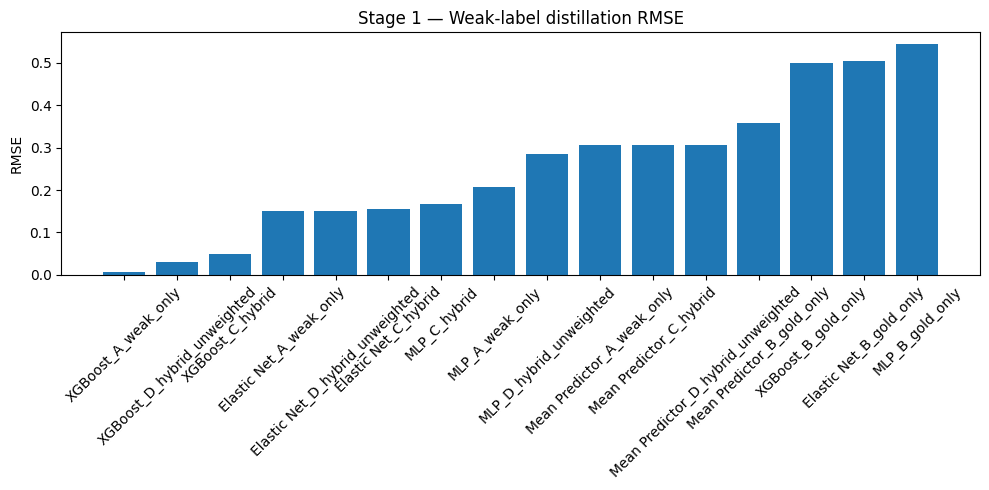

Saved figure: /Users/Thomas/Desktop/Master Thesis/reports/figures/stage1_layer_a_rmse_v036.png


In [17]:
# --- Plot 1: Layer A weak-label RMSE
df_plot_a = df_layer_a.sort_values("rmse", ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(df_plot_a["model"], df_plot_a["rmse"])
ax.set_title("Stage 1 — Weak-label distillation RMSE")
ax.set_ylabel("RMSE")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()

path_fig_a = save_figure_versioned(fig, "stage1_layer_a_rmse")
plt.show()

print("Saved figure:", path_fig_a)

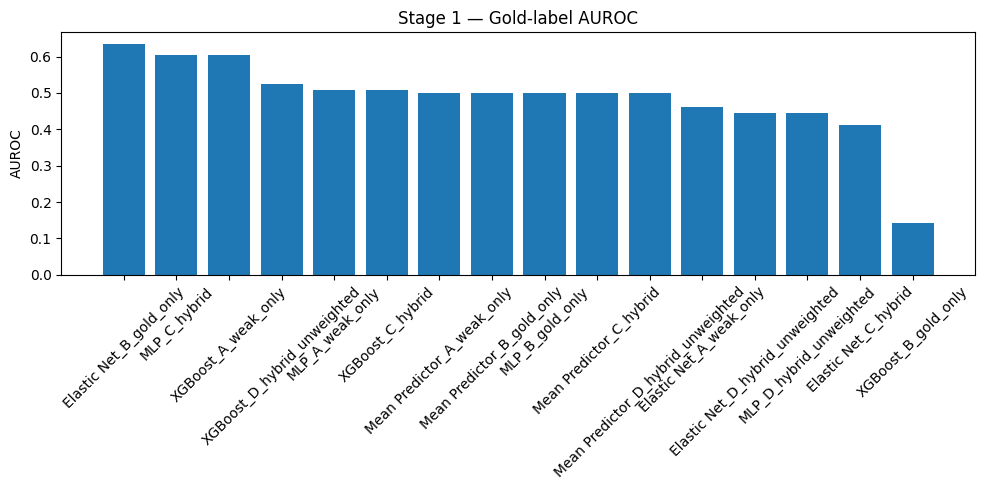

Saved figure: /Users/Thomas/Desktop/Master Thesis/reports/figures/stage1_gold_auroc_v036.png


In [18]:
# --- Plot 2: Layer B gold-label AUROC
df_plot_b_auc = df_layer_b.sort_values("gold_auroc", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(df_plot_b_auc["model"], df_plot_b_auc["gold_auroc"])
ax.set_title("Stage 1 — Gold-label AUROC")
ax.set_ylabel("AUROC")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()

path_fig_b_auc = save_figure_versioned(fig, "stage1_gold_auroc")
plt.show()

print("Saved figure:", path_fig_b_auc)

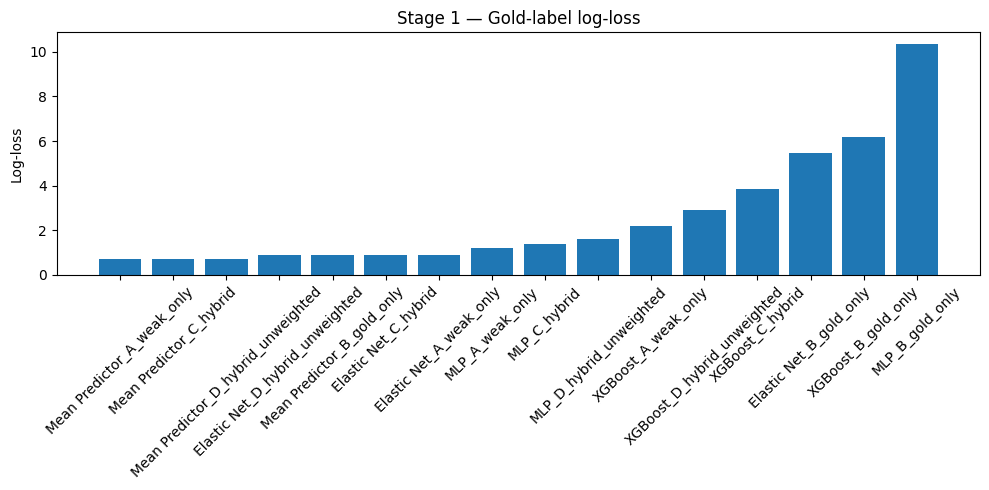

Saved figure: /Users/Thomas/Desktop/Master Thesis/reports/figures/stage1_gold_logloss_v036.png


In [19]:
# --- Plot 3: Layer B gold-label log-loss
df_plot_b_logloss = df_layer_b.sort_values("gold_logloss", ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(df_plot_b_logloss["model"], df_plot_b_logloss["gold_logloss"])
ax.set_title("Stage 1 — Gold-label log-loss")
ax.set_ylabel("Log-loss")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()

path_fig_b_logloss = save_figure_versioned(fig, "stage1_gold_logloss")
plt.show()

print("Saved figure:", path_fig_b_logloss)

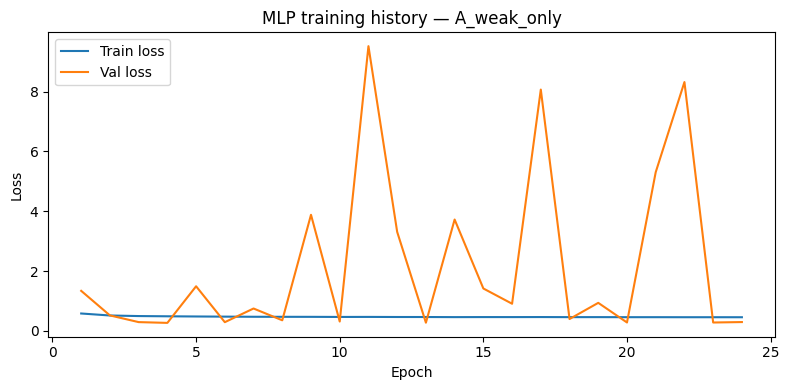

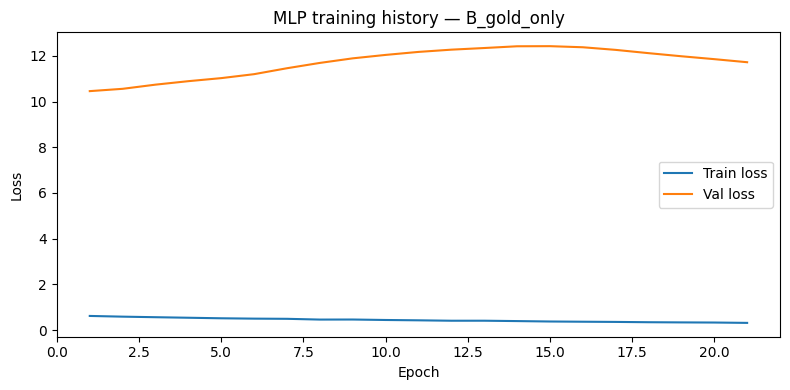

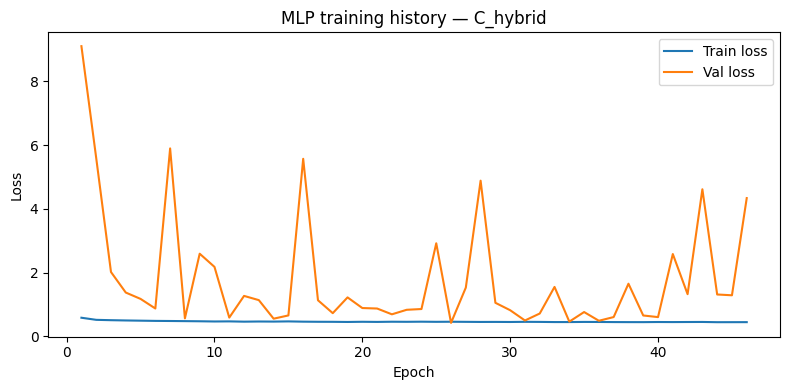

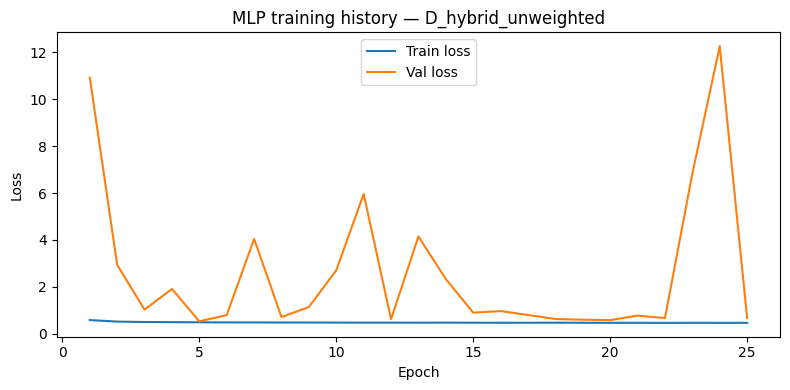

{'A_weak_only': PosixPath('/Users/Thomas/Desktop/Master Thesis/reports/figures/stage1_mlp_history_A_weak_only_v036.png'),
 'B_gold_only': PosixPath('/Users/Thomas/Desktop/Master Thesis/reports/figures/stage1_mlp_history_B_gold_only_v036.png'),
 'C_hybrid': PosixPath('/Users/Thomas/Desktop/Master Thesis/reports/figures/stage1_mlp_history_C_hybrid_v036.png'),
 'D_hybrid_unweighted': PosixPath('/Users/Thomas/Desktop/Master Thesis/reports/figures/stage1_mlp_history_D_hybrid_unweighted_v019.png')}

In [20]:
# --- Plot 4: MLP training history per condition
mlp_history_paths = {}

for condition_name, trained_bundle in trained_bundles.items():
    df_history = trained_bundle["mlp_bundle"]["history"].copy()

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(df_history["epoch"], df_history["train_loss"], label="Train loss")
    ax.plot(df_history["epoch"], df_history["val_loss"], label="Val loss")
    ax.set_title(f"MLP training history — {condition_name}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    plt.tight_layout()

    fig_path = save_figure_versioned(fig, f"stage1_mlp_history_{condition_name}")
    mlp_history_paths[condition_name] = fig_path
    plt.show()

mlp_history_paths

## 11. Final summary views

The final tables consolidate the Stage 1 evidence base. They should be interpreted as the baseline layer that precedes Stage 2 adaptation. In particular, the summary should be read together with the design rule that the target department's weak labels were included in Stage 1, while its gold labels were held out from all supervised training conditions.

In [21]:
# Select gold-label summary columns — only include ranking metrics if present.
_gold_summary_cols = [
    "model", "condition", "model_base",
    "gold_auroc", "gold_ap", "gold_logloss", "gold_brier", "gold_ece",
    "gold_f1", "gold_accuracy",
    "precision_at_5", "precision_at_10", "precision_at_20",
    "recall_at_5", "recall_at_10", "recall_at_20",
    "ndcg_at_5", "ndcg_at_10", "ndcg_at_20",
]
_available_cols = [c for c in _gold_summary_cols if c in df_layer_b.columns]
_missing_cols = [c for c in _gold_summary_cols if c not in df_layer_b.columns]
if _missing_cols:
    print(f"Note: {len(_missing_cols)} ranking columns missing (gold test set too small): {_missing_cols}")

df_gold_summary = df_layer_b[_available_cols].copy()
display(df_gold_summary.sort_values(["gold_auroc", "gold_ap"], ascending=False))


,model,condition,model_base,gold_auroc,gold_ap,gold_logloss,gold_brier,gold_ece,gold_f1,gold_accuracy,precision_at_5,precision_at_10,precision_at_20,recall_at_5,recall_at_10,recall_at_20,ndcg_at_5,ndcg_at_10,ndcg_at_20
5,Elastic Net_B_gold_only,B_gold_only,Elastic Net,0.634921,0.545040,5.470492,0.527605,0.560091,0.608696,0.4375,0.4,0.6,0.4375,0.285714,0.857143,1.0,0.555556,0.729157,0.796406
11,MLP_C_hybrid,C_hybrid,MLP,0.603175,0.727435,1.366215,0.348439,0.346701,0.000000,0.5625,0.8,0.4,0.4375,0.571429,0.571429,1.0,0.853932,0.692079,0.904721
2,XGBoost_A_weak_only,A_weak_only,XGBoost,0.603175,0.698214,2.196919,0.324345,0.320171,0.000000,0.5625,0.8,0.5,0.4375,0.571429,0.714286,1.0,0.830420,0.752481,0.888448
14,XGBoost_D_hybrid_unweighted,D_hybrid_unweighted,XGBoost,0.523810,0.654435,2.916138,0.316970,0.291333,0.000000,0.5625,0.6,0.4,0.4375,0.428571,0.571429,1.0,0.699215,0.658312,0.866476
3,MLP_A_weak_only,A_weak_only,MLP,0.507937,0.670663,1.190990,0.337828,0.306684,0.000000,0.5625,0.6,0.4,0.4375,0.428571,0.571429,1.0,0.722727,0.672456,0.878781
10,XGBoost_C_hybrid,C_hybrid,XGBoost,0.507937,0.661990,3.855390,0.320808,0.318706,0.000000,0.5625,0.6,0.4,0.4375,0.428571,0.571429,1.0,0.699215,0.658312,0.864637
0,Mean Predictor_A_weak_only,A_weak_only,Mean Predictor,0.500000,0.437500,0.710999,0.258891,0.113125,0.608696,0.4375,0.0,0.2,0.4375,0.000000,0.285714,1.0,0.437500,0.546401,0.734298
4,Mean Predictor_B_gold_only,B_gold_only,Mean Predictor,0.500000,0.437500,0.881622,0.334564,0.297440,0.608696,0.4375,0.0,0.2,0.4375,0.000000,0.285714,1.0,0.437500,0.546401,0.734298
7,MLP_B_gold_only,B_gold_only,MLP,0.500000,0.437500,10.361633,0.562500,0.562500,0.608696,0.4375,0.0,0.2,0.4375,0.000000,0.285714,1.0,0.437500,0.546401,0.734298
8,Mean Predictor_C_hybrid,C_hybrid,Mean Predictor,0.500000,0.437500,0.711759,0.259267,0.114775,0.608696,0.4375,0.0,0.2,0.4375,0.000000,0.285714,1.0,0.437500,0.546401,0.734298
